In [1]:
# Stochastic Volatility Model with Predictions

# Imports & Settings
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import pymc as pm
import arviz as az

sns.set_style("whitegrid")
az.style.use("arviz-darkgrid")

RANDOM_SEED = 58
rng = np.random.default_rng(RANDOM_SEED)

## Load and Prepare Data

# Load QQQ data
prices = (
    pd.read_hdf("../data/assets.h5", key="stooq/us/nasdaq/etfs/prices")
    .loc[["QQQ.US"], "close"]
    .droplevel("ticker")
)
log_returns = np.log(prices).diff().dropna()

# Split data into train and test sets (using last year as test)
train_data = log_returns[:-252]  # All but last year
test_data = log_returns[-252:]  # Last year

print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

## Define and Fit Model


def build_sv_model(returns):
    """Build stochastic volatility model for given returns data"""

    with pm.Model() as model:
        returns_data = pm.MutableData("returns_data", returns, dims="obs_id")

        # Priors
        step_size = pm.Exponential("sigma", 50.0)
        s = pm.GaussianRandomWalk("s", sigma=step_size, dims="obs_id")
        nu = pm.Exponential("nu", 0.1)

        # Likelihood
        r = pm.StudentT(
            "r", nu=nu, lam=pm.math.exp(-2 * s), observed=returns, dims="obs_id"
        )

    return model


# Build and fit model on training data
model = build_sv_model(train_data)

Training data shape: (4778,)
Test data shape: (252,)


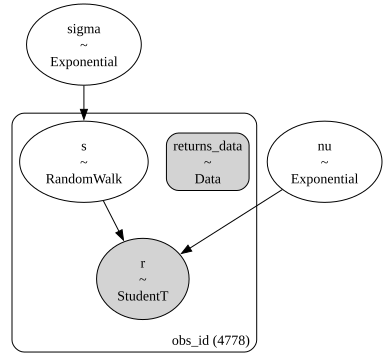

In [2]:
pm.model_to_graphviz(model)

In [3]:
with model:
    trace = pm.sample(
        tune=2000,
        draws=5000,
        chains=4,
        cores=1,
        target_accept=0.9,
        progressbar=True,
        return_inferencedata=True,
        random_seed=rng,
        nuts_sampler="nutpie",
    )

Progress,Draws,Divergences,Step Size,Gradients/Draw
,7000,0,0.06,511
,7000,0,0.06,511
,7000,0,0.06,511
,7000,0,0.06,511


In [43]:
## Make Predictions
# Function to make predictions on test data
def predict_volatility(model, trace, test_data):
    """Make predictions for test data using the fitted model"""

    with model:
        pm.set_data({"returns_data": test_data})
        trace = pm.sample_posterior_predictive(trace, var_names=["s"])

        return trace


# Generate predictions
trace = predict_volatility(model, trace, test_data)

Sampling: [s]


<Axes: title={'center': 'sigma'}>

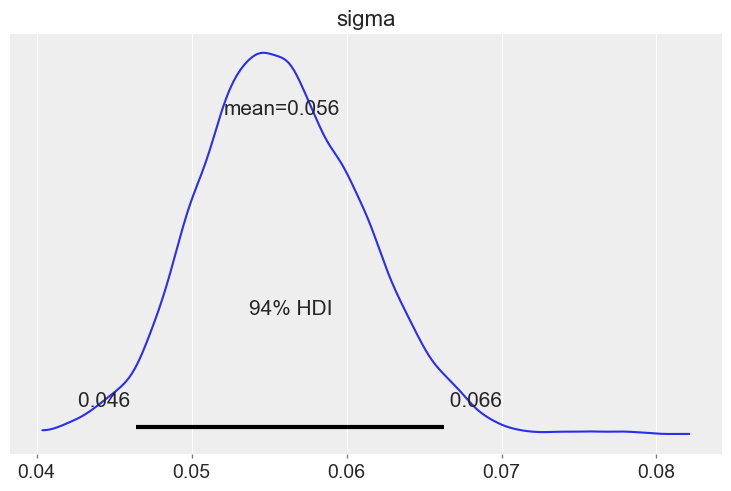

In [17]:
# 6. Plot the step size distribution
az.plot_posterior(trace, var_names=["sigma"])

<Axes: >

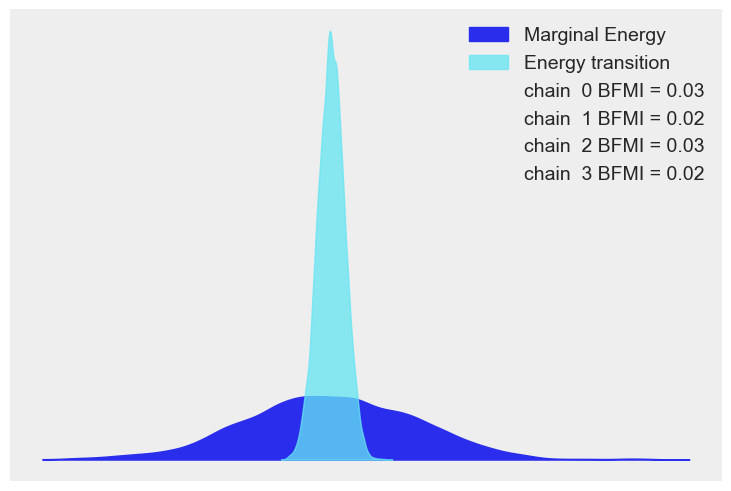

In [18]:
# 5. Energy plot
az.plot_energy(trace)

In [44]:
trace

Inference data with groups:
	> posterior_predictive
	> observed_data
	> constant_data

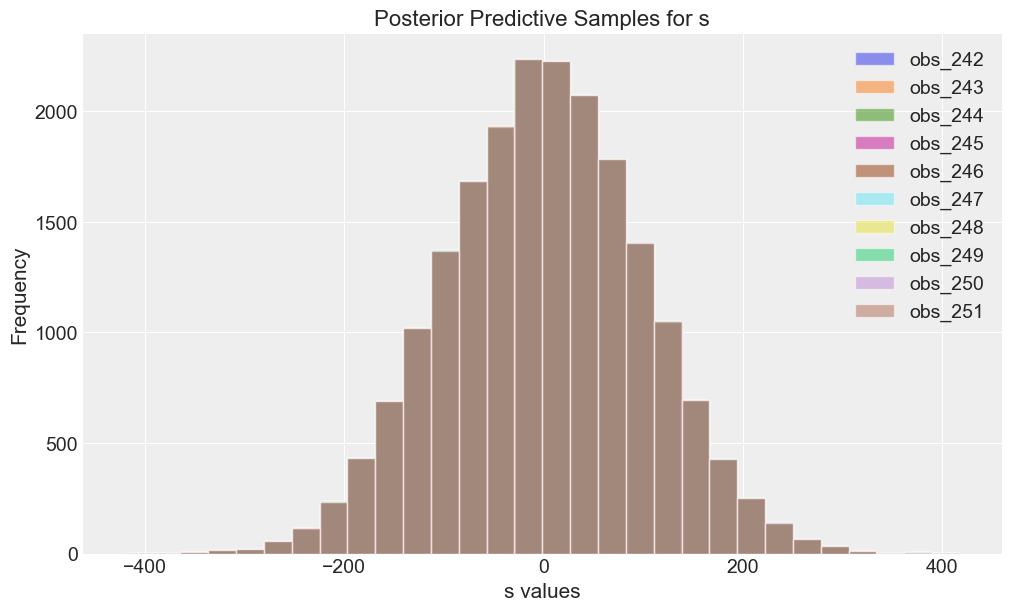

In [51]:
# 4. Posterior predictive check for the last 10 points
# az.plot_ppc(trace, var_names=['s'], coords={'obs_id': ids})
# Just plot the posterior predictive samples for 's'
s_pred = trace.posterior_predictive.s.isel(obs_id=ids)

fig, ax = plt.subplots(figsize=(10, 6))
for i in range(len(ids)):
    # Plot samples for each observation
    samples = s_pred.isel(obs_id=i).values.flatten()
    ax.hist(samples, alpha=0.5, label=f"obs_{ids[i]}", bins=30)

ax.set_xlabel("s values")
ax.set_ylabel("Frequency")
ax.set_title("Posterior Predictive Samples for s")
ax.legend()
plt.show()

In [49]:
ids = trace.posterior_predictive.obs_id.values[-10:]

In [50]:
ids

array([242, 243, 244, 245, 246, 247, 248, 249, 250, 251])

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

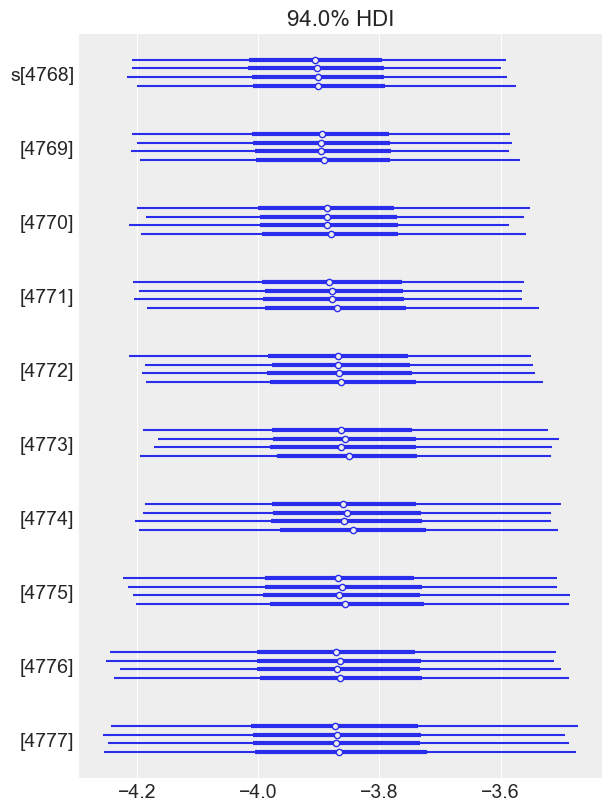

In [36]:
# 3. Forest plot for the last 10 points
az.plot_forest(trace, var_names=["s"], coords={"obs_id": ids})

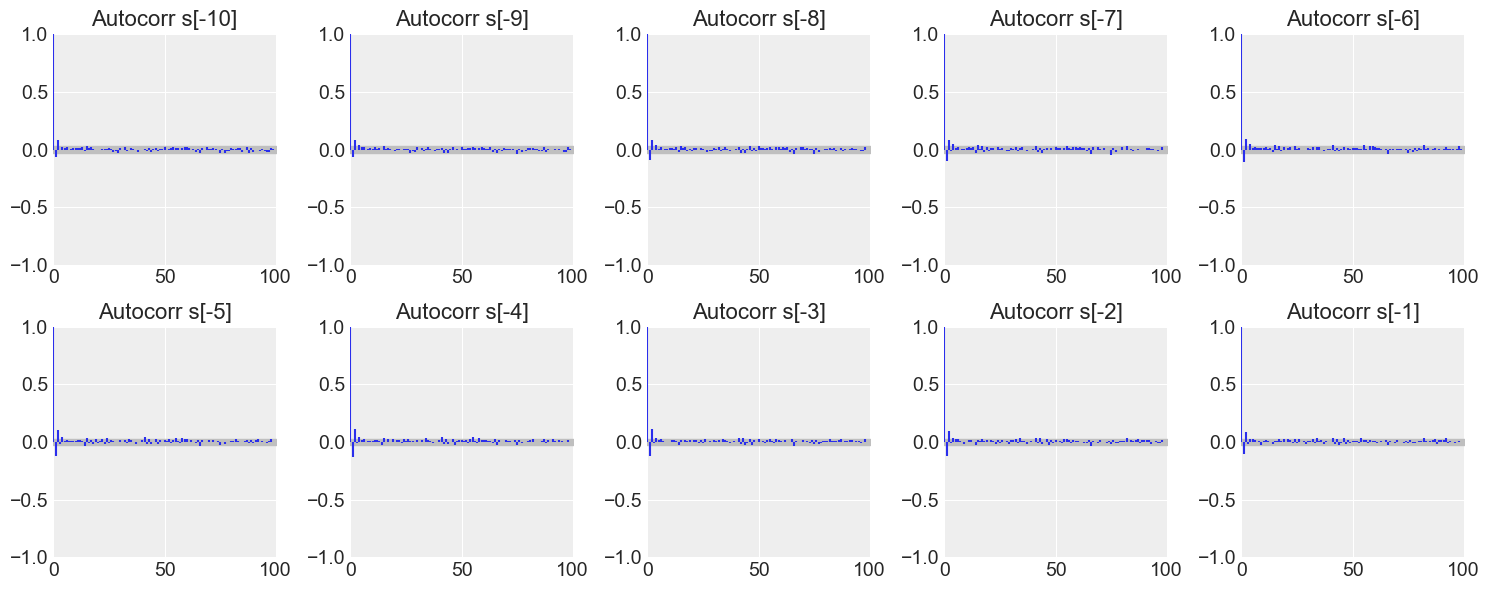

In [41]:
# 2. Autocorrelation plot for the last 10 points
# az.plot_autocorr(trace, var_names=['s'], coords={'obs_id': ids})

# Get the last 10 observations
s_last_10 = trace.posterior.s.isel(obs_id=slice(-10, None))

# Plot autocorr for each of the last 10 observations
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    # Extract one observation across all chains and draws
    s_obs = s_last_10.isel(obs_id=i)

    # Compute autocorrelation manually or use ArviZ on subset
    az.plot_autocorr(s_obs, ax=axes[i])
    axes[i].set_title(f"Autocorr s[{-10 + i}]")

plt.tight_layout()

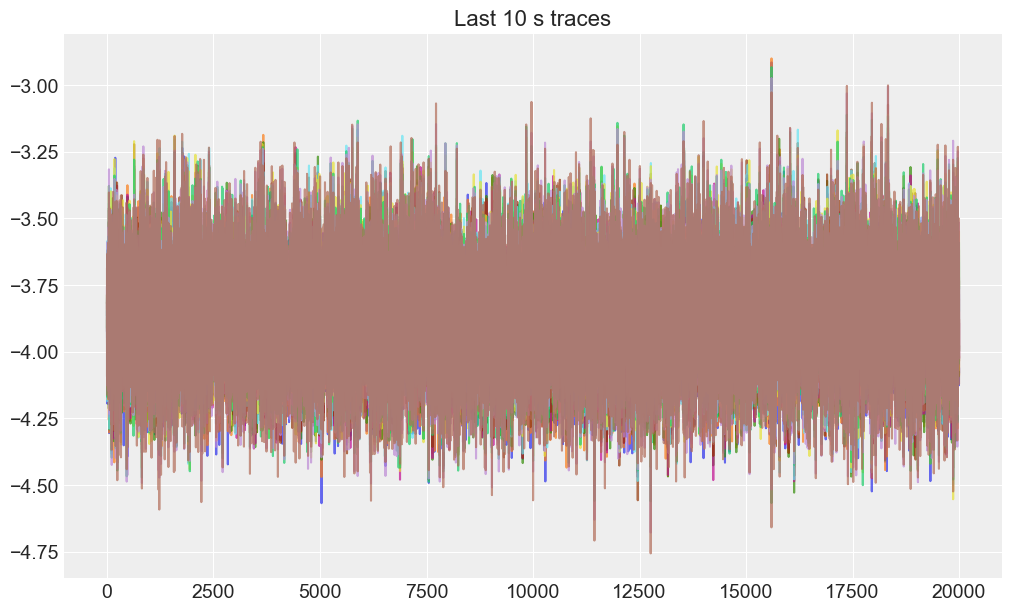

In [40]:
# 1. Trace plot for the last 10 points
# az.plot_trace(trace, var_names=['s'], coords={'obs_id': slice(-10, None)})
# Create your own simple trace plot
fig, ax = plt.subplots(figsize=(10, 6))
s_data = trace.posterior.s.isel(obs_id=slice(-10, None))
for i in range(s_data.obs_id.size):
    ax.plot(s_data.isel(obs_id=i).values.ravel(), alpha=0.7, label=f"obs_{i}")
ax.set_title("Last 10 s traces")
plt.show()

In [16]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_log__,-2.891,0.096,-3.065,-2.710,0.009,0.005,106.0,222.0,1.05
s[0],-3.146,0.188,-3.504,-2.796,0.002,0.001,11101.0,17484.0,1.00
s[1],-3.152,0.183,-3.493,-2.805,0.002,0.001,10760.0,16252.0,1.00
s[2],-3.155,0.176,-3.484,-2.823,0.002,0.001,10149.0,16685.0,1.00
s[3],-3.162,0.172,-3.491,-2.846,0.002,0.001,9817.0,14855.0,1.00
...,...,...,...,...,...,...,...,...,...
s[4776],-3.866,0.198,-4.230,-3.490,0.001,0.001,21389.0,15764.0,1.00
s[4777],-3.868,0.206,-4.259,-3.489,0.001,0.001,21331.0,15291.0,1.00
nu_log__,2.626,0.220,2.223,3.029,0.004,0.002,2421.0,7997.0,1.00
sigma,0.056,0.005,0.046,0.066,0.001,0.000,106.0,222.0,1.05


In [4]:
import xarray as xr

In [5]:
# First, get the last value of s from the training period for each chain
last_s_values = trace.posterior["s"].isel(obs_id=-1).values  # Shape: (chains, draws)

# Generate predictions for test period
n_test = len(test_data)
n_chains, n_draws = last_s_values.shape

# Initialize array for predictions
s_predictions = np.zeros((n_chains, n_draws, n_test))

# For each chain and draw, generate the random walk
for chain in range(n_chains):
    for draw in range(n_draws):
        # Start from the last value of s from training
        s_predictions[chain, draw, 0] = last_s_values[chain, draw]

        # Generate the rest of the random walk
        for t in range(1, n_test):
            # Get the step size for this chain/draw
            step_size = trace.posterior["sigma"].isel(chain=chain, draw=draw).values
            # Generate next step
            s_predictions[chain, draw, t] = s_predictions[
                chain, draw, t - 1
            ] + np.random.normal(0, step_size)

# Convert to xarray for easier handling
s_predictions = xr.DataArray(
    s_predictions,
    dims=["chain", "draw", "obs_id"],
    coords={
        "chain": trace.posterior.chain,
        "draw": trace.posterior.draw,
        "obs_id": range(n_test),
    },
)

In [6]:
mean_s = s_predictions.mean(dim=["chain", "draw"])
std_s = s_predictions.std(dim=["chain", "draw"])

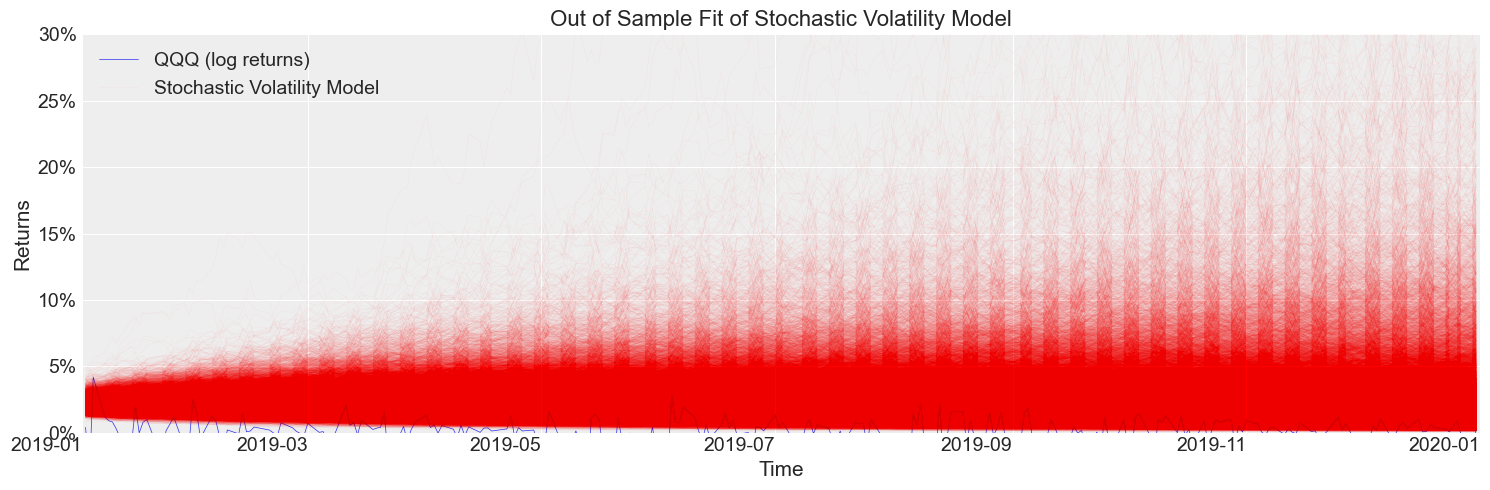

In [7]:
fig, ax = plt.subplots(figsize=(15, 5))

test_data.plot(
    ax=ax,
    lw=0.5,
    xlim=("2019", "2020"),
    rot=0,
    title="Out of Sample Fit of Stochastic Volatility Model",
)

# Get posterior samples for s and reshape to match the plotting needs
s_samples = s_predictions.values  # shape: (chain, draw, time)
s_samples = s_samples.reshape(-1, s_samples.shape[-1])  # reshape to (chain*draw, time)

ax.set_ylim(0, 0.30)

# Plot each sample path
ax.plot(test_data.index, np.exp(s_samples.T), "r", alpha=0.03, lw=0.5)

ax.set(xlabel="Time", ylabel="Returns")
ax.legend(["QQQ (log returns)", "Stochastic Volatility Model"])
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: "{:.0%}".format(y)))

sns.despine()
fig.tight_layout()

In [8]:
## Evaluate Predictions


def evaluate_predictions(actual_returns, predicted_vol):
    """Calculate basic evaluation metrics, handling NaN values."""

    # Calculate realized volatility (using rolling window)
    realized_vol = actual_returns.rolling(window=21).std()

    first_valid_idx = realized_vol.first_valid_index()
    if first_valid_idx is None:
        print("Error: Realized volatility has no valid data points.")
        return np.nan, np.nan

    # Create a Series for predicted_vol using the relevant part of the index from actual_returns
    # This assumes predicted_vol starts from where realized_vol becomes valid.
    # If predicted_vol was generated for the *entire* test period, you'd need to adjust its index.
    predicted_vol_series = pd.Series(
        predicted_vol[20:], index=actual_returns.loc[first_valid_idx:].index
    )

    # Ensure both series are aligned and drop NaNs introduced by the rolling window
    # or any NaNs present in predicted_vol
    # Use .align to ensure they have the same index and then dropna
    realized_vol, predicted_vol = realized_vol.align(predicted_vol_series, join="inner")

    # Drop any remaining NaNs (e.g., from the start of realized_vol)
    # This is crucial for np.mean to work correctly
    combined_data = pd.DataFrame(
        {"realized": realized_vol, "predicted": predicted_vol}
    ).dropna()

    # If after dropping NaNs, there's no data left, handle it gracefully
    if combined_data.empty:
        print("Warning: No overlapping non-NaN data points for evaluation.")
        return np.nan, np.nan

    realized_vol_clean = combined_data["realized"]
    predicted_vol_clean = combined_data["predicted"]

    # Calculate metrics on the cleaned data
    mse = np.mean((realized_vol_clean - predicted_vol_clean) ** 2)
    mae = np.mean(np.abs(realized_vol_clean - predicted_vol_clean))

    print(f"Mean Squared Error: {mse:.6f}")
    print(f"Mean Absolute Error: {mae:.6f}")

    return mse, mae


predict_volatility_samples = np.exp(s_predictions.values)
predicted_vol = np.mean(predict_volatility_samples, axis=(0, 1))

# Evaluate predictions
mse, mae = evaluate_predictions(test_data, predicted_vol)

Mean Squared Error: 0.000318
Mean Absolute Error: 0.017224


In [ ]:
from typing import Tuple, List, Dict
from scipy.stats import spearmanr


def create_time_series_splits(
    data: pd.Series,
    train_size: int = 252,  # 1 year of trading days
    test_size: int = 21,  # 1 month of trading days
    step_size: int = 21,
) -> List[Tuple[pd.Series, pd.Series]]:
    """
    Create time series cross-validation splits using a rolling window approach.

    Args:
        data: Time series data
        train_size: Size of training window in days
        test_size: Size of test window in days
        step_size: Number of days to move forward for each split

    Returns:
        List of (train, test) splits
    """
    splits = []
    n_splits = (len(data) - train_size - test_size) // step_size + 1

    for i in range(n_splits):
        train_start = i * step_size
        train_end = train_start + train_size
        test_end = train_end + test_size

        train_data = data.iloc[train_start:train_end]
        test_data = data.iloc[train_end:test_end]

        splits.append((train_data, test_data))

    return splits


def run_cross_validation(
    data: pd.Series,
    build_model_fn,
    predict_fn,
    train_size: int = 252,
    test_size: int = 21,
    step_size: int = 21,
) -> Dict:
    """
    Run time series cross-validation for the stochastic volatility model.

    Args:
        data: Time series data
        build_model_fn: Function to build the model
        predict_fn: Function to make predictions
        train_size: Size of training window
        test_size: Size of test window
        step_size: Step size for rolling window

    Returns:
        Dictionary containing predictions and metrics
    """
    splits = create_time_series_splits(data, train_size, test_size, step_size)

    all_predictions = []
    all_actuals = []
    metrics = []

    for i, (train_data, test_data) in enumerate(splits):
        # Build and fit model
        model = build_model_fn(train_data)
        with model:
            trace = pm.sample(
                tune=2000,
                draws=5000,
                chains=4,
                cores=1,
                target_accept=0.9,
                progressbar=True,
                nuts_sampler="nutpie",
            )

        # Make predictions
        predicted_vol = predict_fn(model, trace, test_data)

        # Calculate realized volatility
        realized_vol = test_data.rolling(window=21).std()

        # Store predictions and actuals
        all_predictions.extend(predicted_vol)
        all_actuals.extend(realized_vol)

        # Calculate metrics for this split
        split_metrics = {
            "split": i,
            "mse": np.mean((realized_vol - predicted_vol) ** 2),
            "mae": np.mean(np.abs(realized_vol - predicted_vol)),
            "ic": spearmanr(realized_vol, predicted_vol)[0],
        }
        metrics.append(split_metrics)

    # Aggregate results
    results = {
        "predictions": pd.Series(all_predictions, index=data.index[train_size:]),
        "actuals": pd.Series(all_actuals, index=data.index[train_size:]),
        "metrics": pd.DataFrame(metrics),
    }

    return results


def plot_cv_results(results: Dict):
    """
    Plot cross-validation results.

    Args:
        results: Dictionary containing predictions and metrics
    """
    # Plot predictions vs actuals
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

    # Plot 1: Predictions vs Actuals
    results["predictions"].plot(ax=ax1, label="Predicted Volatility", alpha=0.7)
    results["actuals"].plot(ax=ax1, label="Realized Volatility", alpha=0.7)
    ax1.set_title("Predicted vs Realized Volatility")
    ax1.legend()

    # Plot 2: Rolling Metrics
    results["metrics"].set_index("split").plot(ax=ax2)
    ax2.set_title("Cross-Validation Metrics by Split")

    plt.tight_layout()
    return fig


def evaluate_cv_results(results: Dict) -> Dict:
    """
    Calculate overall evaluation metrics for cross-validation results.

    Args:
        results: Dictionary containing predictions and metrics

    Returns:
        Dictionary of overall metrics
    """
    overall_metrics = {
        "overall_mse": np.mean((results["actuals"] - results["predictions"]) ** 2),
        "overall_mae": np.mean(np.abs(results["actuals"] - results["predictions"])),
        "overall_ic": spearmanr(results["actuals"], results["predictions"])[0],
        "mean_split_mse": results["metrics"]["mse"].mean(),
        "mean_split_mae": results["metrics"]["mae"].mean(),
        "mean_split_ic": results["metrics"]["ic"].mean(),
    }

    return overall_metrics

In [ ]:
# Run cross-validation
cv_results = run_cross_validation(
    data=log_returns,
    build_model_fn=build_sv_model,
    predict_fn=predict_volatility,
    train_size=252,  # 1 year
    test_size=21,  # 1 month
    step_size=21,  # Move forward 1 month at a time
)

# Plot results
plot_cv_results(cv_results)

# Get overall metrics
metrics = evaluate_cv_results(cv_results)
print("Overall Cross-Validation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")